# 09 — Topomap (Nested-CV top-4 channel)

Owner: VT

(a) Topomap visualization: the channel stability counts (S1's O1/O2/Oz dominance vs S2's parieto trio) would be visually compelling on a head plot. mne.viz.plot_topomap with the counts as the "data" array.

## Channel Stability Topographic Maps

These figures visualize channel-selection stability using `results/tables/cca_window_sweep_nested.csv`.

We used the `B_top4_nested` configuration (nested cross-validation top-4 channel selection) and counted how often each recorded channel was selected across all sweep windows.

Three maps are shown:

- Overall (all subjects combined)
- Subject 1
- Subject 2

Only 8 posterior EEG channels were recorded in this dataset (`PO7, PO3, POz, PO4, PO8, O1, Oz, O2`).

For full-head visualization, standard 10–20 montage channels not recorded in the dataset were assigned a value of 0 as neutral anchors to prevent unrealistic interpolation across the scalp.

These maps represent **channel selection frequency / stability**, not neural activation or EEG power.

In [8]:
import ast
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

nested_path = Path("../results/tables/cca_window_sweep_nested.csv")
df = pd.read_csv(nested_path)

recorded_chs = ["PO7", "PO3", "POz", "PO4", "PO8", "O1", "Oz", "O2"]

# Use a fuller 10-10 posterior-inclusive montage for visualization anchors.
plot_chs = [
    "Fp1", "Fpz", "Fp2",
    "AF7", "AF3", "AFz", "AF4", "AF8",
    "F7", "F5", "F3", "F1", "Fz", "F2", "F4", "F6", "F8",
    "FT7", "FC5", "FC3", "FC1", "FCz", "FC2", "FC4", "FC6", "FT8",
    "T7", "C5", "C3", "C1", "Cz", "C2", "C4", "C6", "T8",
    "TP7", "CP5", "CP3", "CP1", "CPz", "CP2", "CP4", "CP6", "TP8",
    "P7", "P5", "P3", "P1", "Pz", "P2", "P4", "P6", "P8",
    "PO7", "PO3", "POz", "PO4", "PO8",
    "O1", "Oz", "O2",
]

nested_rows = df[df["config"] == "B_top4_nested"]

overall_counts = Counter()
s1_counts = Counter()
s2_counts = Counter()

for _, row in nested_rows.iterrows():
    channels_per_block = ast.literal_eval(row["channels_used_per_block"])

    for block_idx, block_channels in enumerate(channels_per_block):
        overall_counts.update(block_channels)

        if block_idx in [0, 1]:
            s1_counts.update(block_channels)
        elif block_idx in [2, 3]:
            s2_counts.update(block_channels)

def scores_for_plot(counts):
    return np.array([counts.get(ch, 0) for ch in plot_chs], dtype=float)

overall_scores = scores_for_plot(overall_counts)
s1_scores = scores_for_plot(s1_counts)
s2_scores = scores_for_plot(s2_counts)

print("Recorded-channel counts:")
print("Overall:", {ch: overall_counts.get(ch, 0) for ch in recorded_chs})
print("S1:", {ch: s1_counts.get(ch, 0) for ch in recorded_chs})
print("S2:", {ch: s2_counts.get(ch, 0) for ch in recorded_chs})

Recorded-channel counts:
Overall: {'PO7': 13, 'PO3': 27, 'POz': 19, 'PO4': 20, 'PO8': 15, 'O1': 19, 'Oz': 24, 'O2': 23}
S1: {'PO7': 4, 'PO3': 12, 'POz': 5, 'PO4': 6, 'PO8': 8, 'O1': 13, 'Oz': 16, 'O2': 16}
S2: {'PO7': 9, 'PO3': 15, 'POz': 14, 'PO4': 14, 'PO8': 7, 'O1': 6, 'Oz': 8, 'O2': 7}


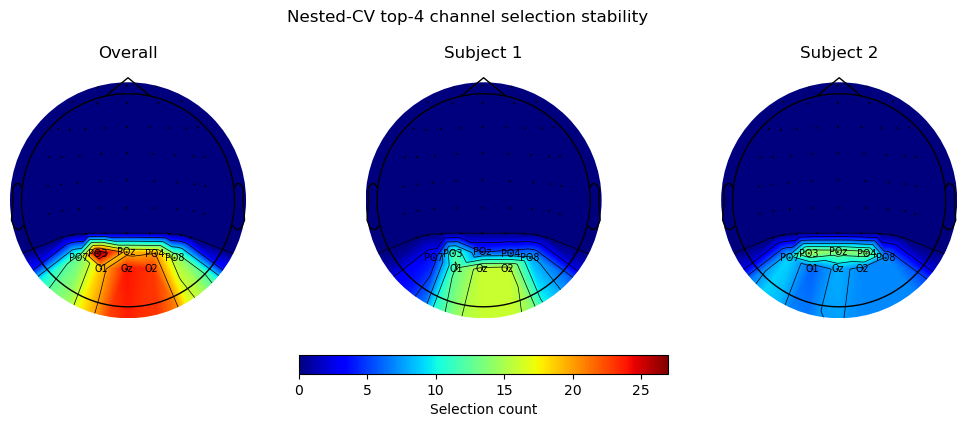

Saved: ../results/figures/channel_stability_topomap_fullhead.png


In [37]:
montage = mne.channels.make_standard_montage("standard_1020")
info = mne.create_info(ch_names=plot_chs, sfreq=256, ch_types="eeg")
info.set_montage(montage)

vmax = max(overall_scores.max(), s1_scores.max(), s2_scores.max())
label_names = [ch if ch in recorded_chs else "" for ch in plot_chs]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, scores, title in [
    (axes[0], overall_scores, "Overall"),
    (axes[1], s1_scores, "Subject 1"),
    (axes[2], s2_scores, "Subject 2"),
]:
    im, _ = mne.viz.plot_topomap(
        scores,
        info,
        axes=ax,
        show=False,
        names=label_names,      # labels only for recorded channels
        sensors=True,           # show electrode dots
        contours=6,
        vlim=(0, vmax),
        cmap="jet",
        extrapolate="head",
        image_interp="linear",
        res=256,
    )
    
    ax.set_title(title)

fig.suptitle("Nested-CV top-4 channel selection stability", y=1.02)

cbar = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.06, pad=0.12)
cbar.set_label("Selection count")

out_dir = Path("../results/figures")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "channel_stability_topomap_fullhead.png"

plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

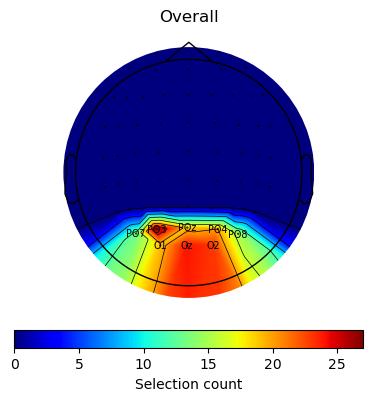

Saved: ../results/figures/channel_stability_topomap_overall.png


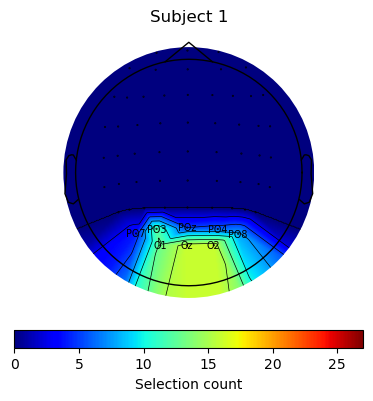

Saved: ../results/figures/channel_stability_topomap_subject1.png


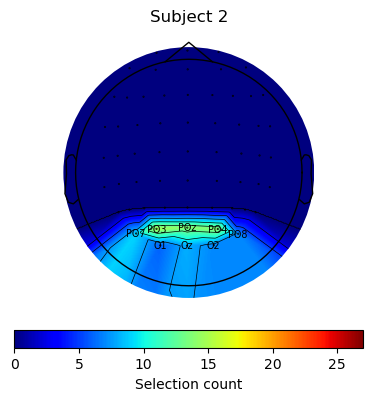

Saved: ../results/figures/channel_stability_topomap_subject2.png


In [38]:
# Save separate topomap figures for slide flexibility

topomap_items = [
    (overall_scores, "Overall", "channel_stability_topomap_overall.png"),
    (s1_scores, "Subject 1", "channel_stability_topomap_subject1.png"),
    (s2_scores, "Subject 2", "channel_stability_topomap_subject2.png"),
]

out_dir = Path("../results/figures")
out_dir.mkdir(parents=True, exist_ok=True)

for scores, title, filename in topomap_items:
    fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.2))

    im, _ = mne.viz.plot_topomap(
        scores,
        info,
        axes=ax,
        show=False,
        names=label_names,      # labels only for recorded channels
        sensors=True,
        contours=6,
        vlim=(0, vmax),
        cmap="jet",
        extrapolate="head",
        image_interp="linear",
        res=256,
    )

    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.07, pad=0.10)
    cbar.set_label("Selection count")

    out_path = out_dir / filename
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)